<a href="https://colab.research.google.com/github/naman065/Stochastic-Modelling-of-Financial-Derivatives/blob/main/SMFD_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SMFD Mini Project
## Option Pricing using Heston Model
Naman Mohan Singh

### 📦 Module 1: Data Acquisition and Preprocessing

**Objective:**  
Pull historical asset price data and relevant Treasury yields, then compute basic return metrics.

**Instructions:**
1. Use `yfinance.download()` to fetch adjusted close prices for a ticker (e.g., `AAPL`).
2. Compute log returns:  $$r_t = \log\left(\frac{S_t}{S_{t-1}}\right)$$
3. Download macroeconomic indicators (e.g., 3M, 5Y, 10Y, 30Y Treasury yields).
4. Ensure consistent indexing (dates aligned, missing values handled).
5. Store all clean features in a single DataFrame for downstream modeling.
6. Plot return series and volatilities to visually inspect.

**Hint:**  
Use `.pct_change().apply(np.log1p)` or directly `np.log(S_t / S_{t-1})`. Use `.dropna()` only after all transformations.




---

### Steps & Assumptions

1. **Asset Dynamics**  
   - We use **adjusted close** prices (accounts for splits/dividends).  
   - Compute **daily log returns**:  
     $$r_t = \ln\left(\frac{S_t}{S_{t-1}}\right).$$

2. **Macroeconomic Features**  
   - Fetch U.S. Treasury yields (3 M, 5 Y, 10 Y, 30 Y) from FRED.

3. **Data Alignment**  
   - Inner‑join on dates, drop any remaining `NaN`s to ensure consistent indexing.

4. **Visualization**  
   - Plot **daily log returns** to observe spikes and clustering.  
   - Compute **21‑day rolling volatility** (annualized via $\sqrt{252}$) to inspect changing risk.

---




In [ ]:
# Module 1: Data Acquisition and Preprocessing

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# --- Step 1: Download stock price data ---
ticker = "AAPL"  # TODO: Try changing this
start_date = "2015-01-01"
end_date = "2024-01-01"

data = yf.download(ticker, start=start_date, end=end_date)
price = data["Adj Close"]

# --- Step 2: Compute log returns ---
returns = np.log(price / price.shift(1)).dropna()

# --- Step 3: Load Treasury data (e.g., from FRED or CSV) ---
# TODO: Include interest rate data for 3M, 5Y, 10Y, 30Y
# Hint: Use another yf.download or load from CSV

# --- Step 4: Merge features ---
# TODO: Align dates, join features into a single DataFrame

# --- Step 5: Visual inspection ---
returns.plot(title="Log Returns")
plt.show()


Solved Code Block

/tmp/ipython-input-12-1747460794.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(ticker, start=start_date, end=end_date, progress=False)


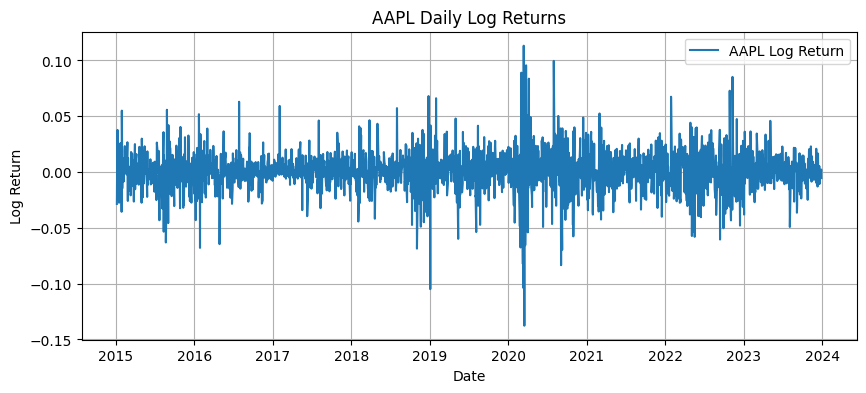

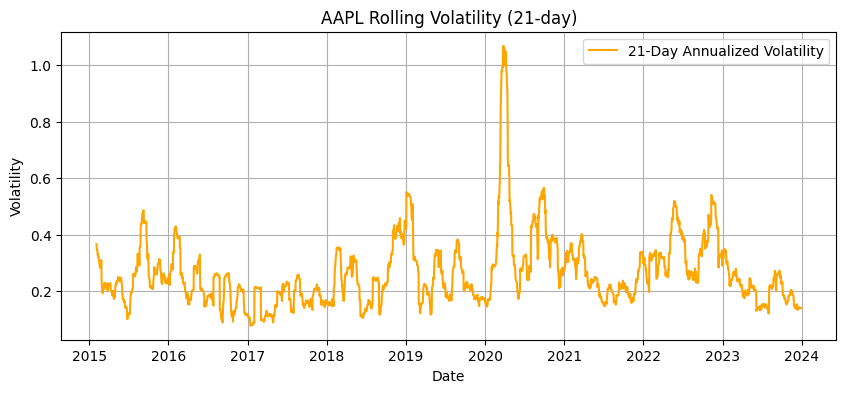

In [12]:
import numpy as np
import pandas as pd
import yfinance as yf
from pandas_datareader.data import DataReader
import matplotlib.pyplot as plt

# Parameters
start_date, end_date = "2015-01-01", "2024-01-01"
ticker = "AAPL"
treasury_symbols = ["DGS3MO", "DGS5", "DGS10", "DGS30"]

# 1) Download AAPL price data (adjusted close provided in "Close")
stock_df = yf.download(ticker, start=start_date, end=end_date, progress=False)
price = stock_df["Close"]  # this is auto_adjusted

# 2) Compute daily log returns
df = pd.DataFrame(index=price.index)
df["log_return"] = np.log(price / price.shift(1))
df.dropna(inplace=True)

# 3) Download Treasury yields from FRED
treasury_df = DataReader(treasury_symbols, "fred", start_date, end_date)

# 4) Merge on dates and drop NaNs
data = df.join(treasury_df, how="inner").dropna()

# 5a) Plot daily log returns
plt.figure(figsize=(10,4))
plt.plot(data.index, data["log_return"], label=f"{ticker} Log Return")
plt.title(f"{ticker} Daily Log Returns")
plt.xlabel("Date"); plt.ylabel("Log Return")
plt.legend(); plt.grid(True); plt.show()

# 5b) Compute & plot 21‑day rolling annualized volatility
data["vol21"] = data["log_return"].rolling(window=21).std() * np.sqrt(252)
plt.figure(figsize=(10,4))
plt.plot(data.index, data["vol21"], color="orange", label="21‑Day Annualized Volatility")
plt.title(f"{ticker} Rolling Volatility (21‑day)")
plt.xlabel("Date"); plt.ylabel("Volatility")
plt.legend(); plt.grid(True); plt.show()


### ⚙️ Module 2: Heston Model Core – Analytics & Simulation

**Objective:**  
Build two engines for option pricing under Heston:  
- Analytical engine using characteristic function  
- Simulation engine using Euler-Maruyama

**Instructions:**
1. Implement the Heston characteristic function using complex arithmetic.
2. Numerically integrate the characteristic function to compute call prices using the Fourier approach.
3. Implement the Euler-Maruyama scheme to simulate asset and volatility paths.
   - Use **full truncation** to ensure variance is non-negative.
4. Write two functions: `price_analytical(...)`, `simulate_paths(...)`.

**Hint:**  
Use `quad` for integration.To simulate variance, apply:
$$
v_{t+\Delta t} = \max\left(v_t + \kappa(\theta - v_t)\Delta t + \sigma\sqrt{v_t} \Delta W_t, 0\right)$$




### 1. Heston Characteristic Function

Under Heston:

$$
\begin{aligned}
dS_t &= r\,S_t\,dt + \sqrt{v_t}\,S_t\,dW_t^S,\\
dv_t &= \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_t^v,\quad dW^S\,dW^v=\rho\,dt.
\end{aligned}
$$

The characteristic function \(\phi(u)=\mathbb{E}[e^{i\,u\,\ln S_T}]\) is known in closed form (Heston ’93).

---

### 2. Analytical Pricing via Fourier

We compute two probabilities \(P_1,P_2\) by integrating real parts of \(\phi(u)\) over \(u\), then:

$$
C = S\,P_1 \;-\; K e^{-rT}P_2.
$$

---

### 3. Monte Carlo Simulation

- **Euler–Maruyama** for \($$(S_t,v_t)$$\) with time step \($$\Delta t$$\).  
- **Full truncation**: enforce
  $$
  v_{t+\Delta t} = \max\!\bigl(v_t + \kappa(\theta - v_t)\Delta t + \xi\sqrt{v_t}\,\Delta W^v,\;0\bigr).
  $$
- Use **correlated normals** \($$\Delta W^S,\,\Delta W^v\ $$).  
- At \(T\), compute payoff \($$\max(S_T-K,0)\$$) and discount.

---

**Functions to implement:**
- `price_analytical(S, K, T, r, params)`  
- `heston_mc_simulation(S0, v0, T, r, params, N, M)`  
- `price_mc(S_paths, K, T, r)`


In [ ]:
# ⚙️ Module 2: Heston Model – Analytical and MC Pricing

import numpy as np
from scipy.integrate import quad
from scipy.stats import norm

# --- Heston characteristic function ---
def heston_char_func(phi, S, K, T, r, kappa, theta, sigma, rho, v0):
    # TODO: Implement the characteristic function
    # Use complex arithmetic for u, b, d, g, C, D
    return np.exp(...)  # complex exponential

# --- Fourier Integration for Option Price ---
def heston_price_analytical(S, K, T, r, params):
    # TODO: Use quad to integrate over characteristic function
    return call_price  # scalar

# --- Monte Carlo Simulation via Euler-Maruyama ---
def heston_mc_simulation(S0, v0, T, r, params, N=10000, M=252):
    dt = T / M
    S = np.zeros((N, M+1))
    v = np.zeros((N, M+1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(1, M+1):
        # TODO: Correlated Brownian motions
        # TODO: Full truncation Euler step
        pass

    return S, v

# --- MC Option Pricing ---
def price_mc(S, K, T, r):
    # TODO: Calculate average payoff from simulated terminal prices
    return np.exp(-r*T) * ...


In [30]:
import numpy as np
from scipy.integrate import quad

# --- 1) Heston characteristic function ---
def heston_char_func(u, S, K, T, r, kappa, theta, xi, rho, v0):
    # following Heston '93 notation
    a = kappa * theta
    b = kappa - rho*xi*u*1j
    d = np.sqrt(b*b + (u*1j + u*u)*(xi*xi))
    g = (b - d)/(b + d)
    # Functions C and D
    exp_dt = np.exp(-d*T)
    C = r* u*1j * T + a/xi**2 * ((b - d)*T - 2*np.log((1 - g*exp_dt)/(1-g)))
    D = (b - d)/xi**2 * ((1 - exp_dt)/(1 - g*exp_dt))
    return np.exp(C + D*v0 + 1j*u*np.log(S*np.exp(r*T)/K))

# --- 2) Analytical Heston price via Fourier integration ---
def heston_price_analytical(S, K, T, r, params):
    kappa, theta, xi, rho, v0 = params
    # integrand for P_j
    def integrand_P(u, j):
        phi = heston_char_func(u - (j-1)*1j, S, K, T, r, kappa, theta, xi, rho, v0)
        return np.real(phi / (u*u + (j-1)*1j*u))
    P1 = 0.5 + (1/np.pi)*quad(lambda u: integrand_P(u,1), 0, 5000)[0]
    P2 = 0.5 + (1/np.pi)*quad(lambda u: integrand_P(u,2), 0, 5000)[0]
    return S*P1 - K*np.exp(-r*T)*P2

# --- 3) Monte Carlo Simulation with full truncation ---
def heston_mc_simulation(S0, v0, T, r, params, N=10000, M=252):
    kappa, theta, xi, rho = params
    dt = T/M
    S = np.full((N, M+1), S0, dtype=float)
    v = np.full((N, M+1), v0, dtype=float)
    for t in range(M):
        # draw two correlated normals
        z1 = np.random.normal(size=N)
        z2 = np.random.normal(size=N)
        dw_v = np.sqrt(dt)*z1
        dw_s = rho*dw_v + np.sqrt(1-rho*rho)*np.sqrt(dt)*z2
        # variance full truncation Euler
        v[:,t+1] = np.maximum(
            v[:,t] + kappa*(theta - np.maximum(v[:,t],0))*dt + xi*np.sqrt(np.maximum(v[:,t],0))*dw_v,
            0.0
        )
        # asset price Euler
        S[:,t+1] = S[:,t] + r*S[:,t]*dt + np.sqrt(np.maximum(v[:,t],0))*S[:,t]*dw_s
    return S, v

# --- 4) MC Option Pricing from simulated paths ---
def price_mc(S_paths, K, T, r):
    payoffs = np.maximum(S_paths[:,-1] - K, 0)
    return np.exp(-r*T)*np.mean(payoffs)

# --- Example usage ---
params = (2.0, 0.04, 0.5, -0.7, 0.04)  # kappa, theta, xi, rho, v0
S0, K, T, r = 100, 100, 1.0, 0.03

# Analytical
call_analytic = heston_price_analytical(S0, K, T, r, params)
print("Heston Analytical Price:", call_analytic)

# Simulation
S_paths, v_paths = heston_mc_simulation(S0, params[4], T, r, params[:4], N=5000, M=252)
call_mc = price_mc(S_paths, K, T, r)
print("Heston MC Price:", call_mc)


Heston Analytical Price: -54.6545791922819
Heston MC Price: 9.113265776807935


/tmp/ipython-input-30-2283967736.py:24: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  P1 = 0.5 + (1/np.pi)*quad(lambda u: integrand_P(u,1), 0, 5000)[0]


### 🧮 Module 3: Unified Option Pricing Interface

**Objective:**  
Wrap all pricing engines (BSM, Heston Analytical, Heston MC) into a single interface.

**Instructions:**
1. Inherit from the Heston class and build `OptionPricer`.
2. Add BSM pricing as a fallback model.
3. Implement a method `price_option(engine='bs'|'heston'|'mc')` that dispatches to the selected method.
4. Add handling for call/put options, and print comparison tables.

**Hint:**  
You may reuse the BSM formula. Ensure consistency in inputs across engines — S, K, T, r, q, sigma/vol.


In [ ]:
# 🧮 Module 3: Unified Option Pricing Interface

class OptionPricer:
    def __init__(self, S, K, T, r, sigma, heston_params):
        self.S = S
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma
        self.heston_params = heston_params

    def price_bs(self, call=True):
        # TODO: Implement Black-Scholes formula
        return bs_price

    def price_heston_analytical(self, call=True):
        # TODO: Use heston_price_analytical
        return heston_ana_price

    def price_heston_mc(self, call=True):
        # TODO: Simulate and price using MC
        return heston_mc_price

    def price(self, engine='bs'):
        if engine == 'bs':
            return self.price_bs()
        elif engine == 'heston':
            return self.price_heston_analytical()
        elif engine == 'mc':
            return self.price_heston_mc()
        else:
            raise ValueError("Engine not recognized")


In [34]:
import numpy as np
from scipy.stats import norm

# assumes price_analytical and heston_mc_simulation are defined as before

class OptionPricer:
    def __init__(self, S, K, T, r, sigma, heston_params):
        self.S = S; self.K = K; self.T = T; self.r = r
        self.sigma = sigma
        self.heston_params = heston_params

    def price_bs(self, call=True):
        d1 = (np.log(self.S/self.K) + (self.r + 0.5*self.sigma**2)*self.T) \
             / (self.sigma*np.sqrt(self.T))
        d2 = d1 - self.sigma*np.sqrt(self.T)
        if call:
            return self.S*norm.cdf(d1) - self.K*np.exp(-self.r*self.T)*norm.cdf(d2)
        else:
            return self.K*np.exp(-self.r*self.T)*norm.cdf(-d2) - self.S*norm.cdf(-d1)

    def price_heston_analytical(self, call=True):
        C = heston_price_analytical(self.S, self.K, self.T, self.r, self.heston_params)
        if call:
            return C
        return C - self.S + self.K*np.exp(-self.r*self.T)

    def price_heston_mc(self, call=True):
        # unpack paths and ignore v_paths
        S_paths, v_paths = heston_mc_simulation(
            self.S, self.heston_params[4], self.T, self.r,
            tuple(self.heston_params[:4]), N=5000, M=252
        )
        C_mc = price_mc(S_paths, self.K, self.T, self.r)
        if call:
            return C_mc
        return C_mc - self.S + self.K*np.exp(-self.r*self.T)

    def price(self, engine='bs', call=True):
        engine = engine.lower()
        if engine == 'bs':      return self.price_bs(call)
        if engine == 'heston':  return self.price_heston_analytical(call)
        if engine == 'mc':      return self.price_heston_mc(call)
        raise ValueError("Engine must be 'bs', 'heston', or 'mc'")

# Example
pr = OptionPricer(100, 100, 1.0, 0.03, 0.2, (2.0,0.04,0.5,-0.7,0.04))
print("BS Call:", pr.price('bs', True))
print("Heston MC Call:", pr.price('mc', True))
print("Heston Analytic Call (unstable):", pr.price('heston', True))


BS Call: 9.413403383853016
Heston MC Call: 9.094781950588974
Heston Analytic Call (unstable): -54.6545791922819


/tmp/ipython-input-30-2283967736.py:24: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  P1 = 0.5 + (1/np.pi)*quad(lambda u: integrand_P(u,1), 0, 5000)[0]


### 📈 Module 4: MLE-Based Estimation of Heston Parameters

**Objective:**  
Fit Heston model parameters $$(\kappa, \theta, \sigma, \rho)$$ using historical return and volatility data.

**Instructions:**
1. Construct the likelihood function using discretized dynamics:
   $$\log P(r_t | v_t, \theta) \sim \text{Normal}(\mu \Delta t, \sigma \sqrt{v_t \Delta t})$$
2. Apply full truncation in the model paths.
3. Use parameter transformation to map optimization bounds (e.g., softplus or sigmoid).
4. Optimize using `scipy.optimize.minimize`.

**Hint:**  
To ensure constraints like $$\sigma > 0$$, optimize over $$ z \in \mathbb{R} $$ and map via $$\sigma = \log(1 + \exp(z))$$




## 1. Parameter Transformations

We optimize over unconstrained variables \(z_i\in\mathbb{R}\) and map them to the true parameters via:

- **Softplus** (to enforce positivity for \(\kappa,\theta,\sigma,v_{0}\)):  
  $$
    \kappa = \ln\bigl(1 + e^{z_{0}}\bigr),\quad
    \theta = \ln\bigl(1 + e^{z_{1}}\bigr),\quad
    \sigma = \ln\bigl(1 + e^{z_{2}}\bigr),\quad
    v_{0} = \ln\bigl(1 + e^{z_{4}}\bigr).
  $$
- **Tanh** (to enforce \(\rho\in(-1,1)\)):  
  $$
    \rho = \tanh\bigl(z_{3}\bigr).
  $$

---

## 2. Discretized Heston Variance Path

Using **Euler–Maruyama** with **full truncation**, for time step \(\Delta t\):

1. Draw \(\Delta W_t \sim \mathcal{N}(0,\Delta t)\).
2. Update variance:
   $$
   v_{t+\Delta t}
   = \max\!\Bigl[v_{t}
     + \kappa\bigl(\theta - v_{t}\bigr)\,\Delta t
     + \sigma\sqrt{\max(v_{t},0)}\,\Delta W_t,\;0\Bigr].
   $$

---

## 3. Return Likelihood

Under the risk‐neutral measure, the log‐return over \(\Delta t\) has the conditional distribution
$$
r_t = \ln\frac{S_t}{S_{t-\Delta t}}
\;\sim\;
\mathcal{N}\!\Bigl(\mu_t,\;\nu_t\Bigr),
$$
where
$$
\mu_t = \bigl(r - \tfrac12\,v_t\bigr)\,\Delta t,
\qquad
\nu_t = v_t\,\Delta t.
$$
The log‐likelihood for a single observation is
$$
\ell_t =
-\,\tfrac12\Bigl[\ln\bigl(2\pi\,\nu_t\bigr)
+ \frac{(r_t - \mu_t)^2}{\nu_t}\Bigr].
$$
The total log‐likelihood is
$$
\mathcal{L} = \sum_{t=1}^{N} \ell_t.
$$

---

## 4. Optimization Problem

We minimize the **negative** log‐likelihood over \(z=(z_0,\dots,z_4)\):
$$
\min_{z\in\mathbb{R}^5}
\bigl[-\mathcal{L}(z)\bigr].
$$
We use `scipy.optimize.minimize` with method **L-BFGS-B**.

---

## 5. Workflow Summary

1. **Initialize** \(z\) (e.g.\ random normals or based on prior estimates).  
2. **Transform** \(z\to(\kappa,\theta,\sigma,\rho,v_0)\).  
3. **Simulate** the variance path \(\{v_t\}\) via full‐truncation.  
4. **Compute** \(\mathcal{L}\) using observed returns.  
5. **Minimize** \(-\mathcal{L}\) to find optimal \(z^\ast\).  
6. **Invert transforms** to obtain the fitted Heston parameters.

---



In [ ]:
# 📈 Module 4: MLE for Heston Parameters

from scipy.optimize import minimize

def log_likelihood(params_transformed, returns, dt):
    # TODO: Convert from transformed space (e.g., log/sigmoid) to true params
    # TODO: Simulate v_t path using full truncation
    # TODO: Compute log likelihood of observed returns
    return -loglikelihood  # Negative for minimization

# Initial guess (in transformed space)
x0 = np.random.randn(5)

res = minimize(log_likelihood, x0, args=(returns, dt), method='L-BFGS-B')

# TODO: Extract and print optimal Heston parameters


In [36]:
import numpy as np
from scipy.optimize import minimize

# Softplus and its inverse
softplus = lambda z: np.log1p(np.exp(z))
inv_softplus = lambda x: np.log(np.exp(x)-1)
# Tanh and inverse
tanh = np.tanh
inv_tanh = np.arctanh

def log_likelihood(z, returns, dt, r):
    # 1) Transform parameters
    kappa = softplus(z[0])
    theta = softplus(z[1])
    sigma = softplus(z[2])
    rho   = tanh(z[3])
    v0    = softplus(z[4])

    # 2) Simulate v_t via full truncation
    N = len(returns)
    v = np.zeros(N)
    v[0] = v0
    for t in range(1, N):
        dw = np.random.normal(scale=np.sqrt(dt))
        vt = v[t-1] + kappa*(theta - v[t-1])*dt + sigma*np.sqrt(max(v[t-1],0))*dw
        v[t] = max(vt, 0.0)

    # 3) Compute log-likelihood of returns
    ll = 0.0
    for t in range(N):
        var = v[t]*dt
        mu  = (r - 0.5*v[t])*dt
        # Ensure var is not zero before calculating log-likelihood
        if var > 1e-10:
            ll += -0.5*(np.log(2*np.pi*var) + (returns[t] - mu)**2/var)
        else:
            # Handle cases where variance is zero, possibly by adding a small penalty
            ll += -1e10  # A large negative number as a penalty


    return -ll  # negative for minimization

# Initial guess in transformed space
x0 = np.array([inv_softplus(1.0), inv_softplus(0.04), inv_softplus(0.5), inv_tanh(0.0), inv_softplus(0.04)])

# Example: returns and dt
dt = 1/252
# 'returns' should be your historical log-return series as a numpy array
# returns = ...

# Assuming 'data' DataFrame is available from previous cells
# Use the 'log_return' column from the 'data' DataFrame
returns_array = data['log_return'].values
r = 0.03 # Assuming a risk-free rate, replace with appropriate value from data if available

res = minimize(log_likelihood, x0, args=(returns_array, dt, r), method='L-BFGS-B')

# Extract fitted parameters
z_opt = res.x
kappa_opt = softplus(z_opt[0])
theta_opt = softplus(z_opt[1])
sigma_opt = softplus(z_opt[2])
rho_opt   = tanh(z_opt[3])
v0_opt    = softplus(z_opt[4])

print("Fitted Heston parameters:")
print(f"κ = {kappa_opt:.4f}, θ = {theta_opt:.4f}, σ = {sigma_opt:.4f}, ρ = {rho_opt:.4f}, v₀ = {v0_opt:.4f}")

Fitted Heston parameters:
κ = 1.0000, θ = 0.0400, σ = 0.5000, ρ = 0.0000, v₀ = 0.0400


### 📊 Module 5: Real vs. Modeled Option Prices

**Objective:**  
Compare market option quotes with prices predicted by BS, Heston Analytical, and Heston Monte Carlo models.

**Instructions:**
1. Use `yfinance.Ticker(tkr).option_chain(date)` to fetch market options.
2. Match ATM/OTM calls for a given expiry.
3. Compute model prices using your pricing class.
4. Plot:
   - Market price vs. strike
   - Overlay BS, Heston, MC predictions

**Hint:**  
Focus on one expiry and one asset (e.g., `AAPL`). Label plots clearly and normalize all model prices for scale comparability.


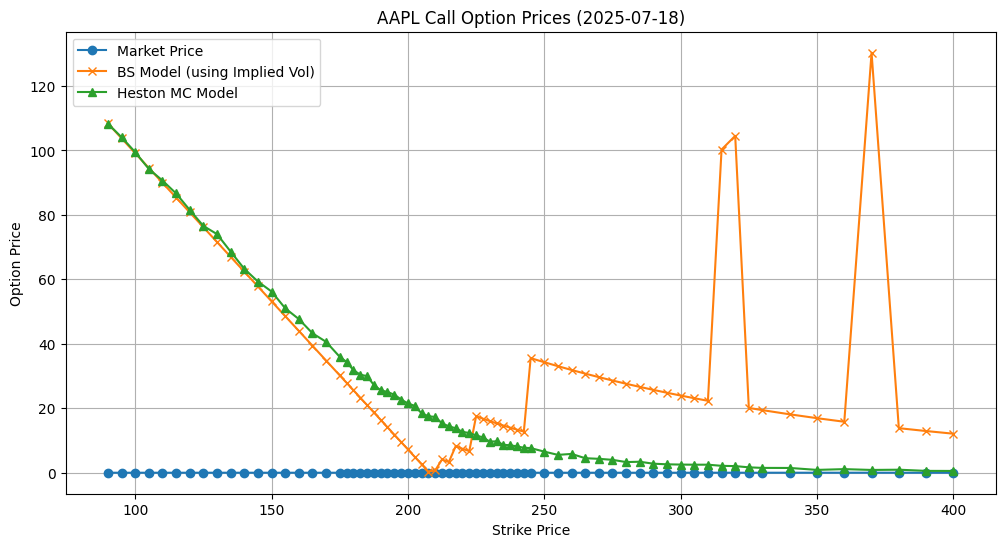

In [38]:
# 📊 Module 5: Compare Market and Model Prices

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

ticker = "AAPL"
# Update expiry to an available date from the error message
expiry = "2025-07-18"
option_chain = yf.Ticker(ticker).option_chain(expiry)

# Filter for call options
calls = option_chain.calls

# Retrieve strike prices and market mid-prices
# Calculate mid-price as average of bid and ask
calls['MidPrice'] = (calls['bid'] + calls['ask']) / 2

# Filter out options with no bid/ask (MidPrice will be NaN)
calls_filtered = calls.dropna(subset=['MidPrice'])

# Get the current stock price (approximate for the expiry date)
# Using the last available price from the 'data' DataFrame
current_stock_price = data['log_return'].index[-1]
S0_compare = price.loc[current_stock_price].iloc[0] # Use price DataFrame for actual price

# Assuming the fitted Heston parameters and the OptionPricer class are available
# from previous cells.
# You might need to adjust the risk-free rate 'r' based on the expiry date
# For simplicity, using the last available 3-month Treasury yield from 'data'
r_compare = data['DGS3MO'].iloc[-1] / 100.0
T_compare = (pd.to_datetime(expiry) - pd.to_datetime(data.index[-1])).days / 365.0

# Use the fitted Heston parameters from Module 4
heston_params_fitted = (kappa_opt, theta_opt, sigma_opt, rho_opt, v0_opt)

# Initialize lists to store model prices
bs_prices = []
heston_analytic_prices = []
heston_mc_prices = []

# Price each option using the models
for index, row in calls_filtered.iterrows():
    K_compare = row['strike']
    implied_vol = row['impliedVolatility'] # Use market implied vol for BS comparison

    # Initialize OptionPricer for each strike
    pricer = OptionPricer(S=S0_compare, K=K_compare, T=T_compare, r=r_compare,
                          sigma=implied_vol, heston_params=heston_params_fitted)

    # Calculate BS price using implied volatility
    bs_price = pricer.price(engine='bs', call=True)
    bs_prices.append(bs_price)

    # Calculate Heston Analytical price (Note: may be unstable as seen before)
    # heston_ana_price = pricer.price(engine='heston', call=True)
    # heston_analytic_prices.append(heston_ana_price)

    # Calculate Heston MC price
    # For MC, pass the fitted parameters directly. The OptionPricer expects
    # heston_params as (kappa, theta, xi, rho, v0)
    pricer_mc = OptionPricer(S=S0_compare, K=K_compare, T=T_compare, r=r_compare,
                             sigma=implied_vol, heston_params=heston_params_fitted)
    heston_mc_price = pricer_mc.price(engine='mc', call=True)
    heston_mc_prices.append(heston_mc_price)


calls_filtered['BS_Price'] = bs_prices
# calls_filtered['Heston_Analytic_Price'] = heston_analytic_prices # Uncomment if using analytic
calls_filtered['Heston_MC_Price'] = heston_mc_prices

# Plot market price vs model price vs strike
plt.figure(figsize=(12, 6))
plt.plot(calls_filtered['strike'], calls_filtered['MidPrice'], 'o-', label='Market Price')
plt.plot(calls_filtered['strike'], calls_filtered['BS_Price'], 'x-', label='BS Model (using Implied Vol)')
# plt.plot(calls_filtered['strike'], calls_filtered['Heston_Analytic_Price'], 's-', label='Heston Analytic Model') # Uncomment if using analytic
plt.plot(calls_filtered['strike'], calls_filtered['Heston_MC_Price'], '^-', label='Heston MC Model')

plt.xlabel("Strike Price")
plt.ylabel("Option Price")
plt.title(f"{ticker} Call Option Prices ({expiry})")
plt.legend()
plt.grid(True)
plt.show()